c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
Predicted Word : powerful


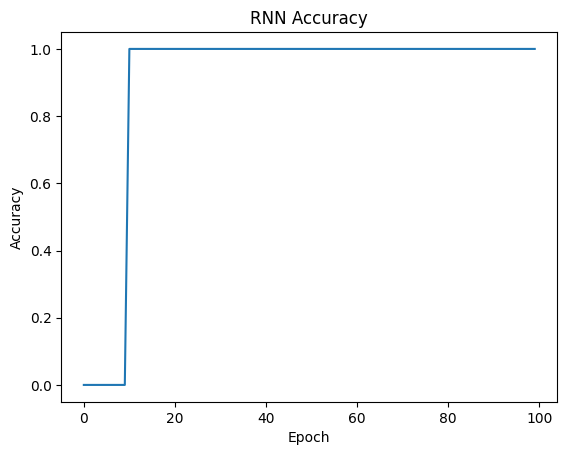

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Text
text = ["deep learning is powerful"]

# Tokenize
tok = Tokenizer()
tok.fit_on_texts(text)

seq = tok.texts_to_sequences(text)[0]

X = np.array([seq[:3]])
y = np.array([seq[3]])

# Model
model = Sequential([
    Embedding(20, 8, input_length=3),
    SimpleRNN(16),
    Dense(20, activation='softmax')
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(X, y, epochs=100, verbose=0)

# Predict
pred = np.argmax(model.predict(X), axis=1)

# Display Word
print("Predicted Word :", tok.index_word[pred[0]])

# Graph
plt.plot(history.history['accuracy'])
plt.title("RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()